# U-Net Segmentation Model

## Import Block
Code for package checks, imports, and random seed setup.

In [1]:
import os
import sys
import subprocess
import pkgutil
import random
from pathlib import Path

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "PIL": "Pillow",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "torch": "torch",
    "torchvision": "torchvision",
}

missing = [pip_name for module_name, pip_name in REQUIRED_PACKAGES.items() if pkgutil.find_loader(module_name) is None]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are already installed.")

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

print("Setup complete")
print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

/tmp/ipykernel_23/899680237.py:18: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  missing = [pip_name for module_name, pip_name in REQUIRED_PACKAGES.items() if pkgutil.find_loader(module_name) is None]


All required packages are already installed.
Setup complete
Python: 3.12.12
Torch: 2.10.0+cu128
CUDA available: True


## Kaggle Unzip Block
Code for extracting the uploaded zip dataset into /kaggle/working before loading CSV files.

In [2]:
import zipfile

kaggle_input_root = Path("/kaggle/input")
kaggle_working_root = Path("/kaggle/working")

if kaggle_input_root.exists() and kaggle_working_root.exists():
    target_master = kaggle_working_root / "data" / "master_pairs.csv"

    if target_master.exists():
        print("Dataset already extracted at:", target_master.parent)
    else:
        zip_files = sorted(kaggle_input_root.rglob("*.zip"))

        if not zip_files:
            print("No zip file found under /kaggle/input. If your dataset is already extracted, continue.")
        else:
            preferred = [p for p in zip_files if "data" in p.name.lower() or "kaggle" in p.name.lower()]
            zip_path = preferred[0] if preferred else zip_files[0]

            print("Extracting zip:", zip_path)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(kaggle_working_root)

            found_csv = sorted(kaggle_working_root.rglob("master_pairs.csv"))
            if found_csv:
                print("Found master_pairs.csv at:", found_csv[0])
            else:
                print("Extraction complete, but master_pairs.csv was not found. Check your zip structure.")
else:
    print("Not running on Kaggle, skipping unzip block.")

No zip file found under /kaggle/input. If your dataset is already extracted, continue.


## Input Data Block
Code for resolving dataset path and loading the cleaned master CSV.

In [3]:
KAGGLE_DATA_CANDIDATES = [
    Path("/kaggle/working/data"),
    Path("/kaggle/input/colon-disease-segmentation-cleaned/data"),
    Path("/kaggle/input/colon-disease-segmentation/data"),
    Path("/kaggle/input/ebhi-seg-cleaned/data"),
]
LOCAL_DATA_CANDIDATES = [
    Path("../data"),
    Path("data"),
]


def resolve_data_root():
    for p in KAGGLE_DATA_CANDIDATES + LOCAL_DATA_CANDIDATES:
        if (p / "master_pairs.csv").exists():
            return p

    search_roots = [Path("/kaggle/working"), Path("/kaggle/input"), Path(".")]
    for root in search_roots:
        if root.exists():
            hits = sorted(root.rglob("master_pairs.csv"))
            if hits:
                return hits[0].parent

    raise FileNotFoundError("Could not find master_pairs.csv in Kaggle or local paths")


DATA_ROOT = resolve_data_root()
MASTER_CSV = DATA_ROOT / "master_pairs.csv"

df = pd.read_csv(MASTER_CSV)

print("DATA_ROOT:", DATA_ROOT)
print("MASTER_CSV:", MASTER_CSV)
print("Total rows in master CSV:", len(df))
print(df.head(3))

DATA_ROOT: /kaggle/input/datasets/thelostleo/data-zip/data
MASTER_CSV: /kaggle/input/datasets/thelostleo/data-zip/data/master_pairs.csv
Total rows in master CSV: 2226
   sample_id      class_name  class_id                 filename  \
0          1  Adenocarcinoma         1  GT2001837-1-400-001.png   
1          2  Adenocarcinoma         1  GT2001837-1-400-002.png   
2          3  Adenocarcinoma         1  GT2001837-1-400-003.png   

                                          image_path  \
0  cleaned/Adenocarcinoma/image/GT2001837-1-400-0...   
1  cleaned/Adenocarcinoma/image/GT2001837-1-400-0...   
2  cleaned/Adenocarcinoma/image/GT2001837-1-400-0...   

                                           mask_path  
0  cleaned/Adenocarcinoma/label/GT2001837-1-400-0...  
1  cleaned/Adenocarcinoma/label/GT2001837-1-400-0...  
2  cleaned/Adenocarcinoma/label/GT2001837-1-400-0...  


## Preprocessing Block
Code for validating paths, cleaning invalid rows, and preparing class targets for segmentation and classification.

In [4]:
required_columns = {"sample_id", "class_name", "class_id", "filename", "image_path", "mask_path"}
missing_columns = required_columns - set(df.columns)
assert not missing_columns, f"Missing required columns: {missing_columns}"

df = df.dropna(subset=["image_path", "mask_path", "class_id"]).copy()
df["class_id"] = df["class_id"].astype(int)

df["image_full_path"] = df["image_path"].apply(lambda x: str((DATA_ROOT / x).resolve()))
df["mask_full_path"] = df["mask_path"].apply(lambda x: str((DATA_ROOT / x).resolve()))

exists_image = df["image_full_path"].apply(lambda x: Path(x).exists())
exists_mask = df["mask_full_path"].apply(lambda x: Path(x).exists())
valid_rows = exists_image & exists_mask

bad_rows = int((~valid_rows).sum())
if bad_rows > 0:
    print(f"Dropping invalid rows with missing files: {bad_rows}")

df = df.loc[valid_rows].reset_index(drop=True)

# Classifier target uses 0..5, segmentation keeps 0..6 with background.
df["clf_target"] = df["class_id"] - 1
NUM_SEG_CLASSES = int(df["class_id"].max()) + 1
NUM_CLS_CLASSES = int(df["class_id"].max())

print("Rows after preprocessing:", len(df))
print("NUM_SEG_CLASSES (with background):", NUM_SEG_CLASSES)
print("NUM_CLS_CLASSES:", NUM_CLS_CLASSES)
print("Class distribution:")
print(df["class_name"].value_counts())

Rows after preprocessing: 2226
NUM_SEG_CLASSES (with background): 7
NUM_CLS_CLASSES: 6
Class distribution:
class_name
Adenocarcinoma      795
Low-grade IN        637
Polyp               474
High-grade IN       186
Normal               76
Serrated adenoma     58
Name: count, dtype: int64


## Split Block
Code for stratified train/validation/test split and saving split CSV files.

In [5]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["class_id"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["class_id"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

RUN_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
ARTIFACTS_DIR = RUN_DIR / "artifacts"
SPLIT_DIR = ARTIFACTS_DIR / "splits"
MODEL_DIR = ARTIFACTS_DIR / "models"

SPLIT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(SPLIT_DIR / "train.csv", index=False)
val_df.to_csv(SPLIT_DIR / "val.csv", index=False)
test_df.to_csv(SPLIT_DIR / "test.csv", index=False)

print("Split sizes -> train:", len(train_df), "val:", len(val_df), "test:", len(test_df))
print("Split files saved in:", SPLIT_DIR)
print("Train class distribution:")
print(train_df["class_name"].value_counts())

Split sizes -> train: 1558 val: 334 test: 334
Split files saved in: /kaggle/working/artifacts/splits
Train class distribution:
class_name
Adenocarcinoma      556
Low-grade IN        446
Polyp               332
High-grade IN       130
Normal               53
Serrated adenoma     41
Name: count, dtype: int64


## Dataset and Dataloader Block
Code for segmentation and classification datasets, normalization, and dataloaders.

In [6]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

IMAGE_SIZE = 224
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

# Quick test switch. Keep True for smoke tests, set False for full training.
TEST_MODE = False
EPOCHS = 1 if TEST_MODE else 50

# Tuned defaults for Kaggle free GPU.
BATCH_SIZE_SEG = 8
BATCH_SIZE_CLS = 32
PATIENCE = 7
LEARNING_RATE_SEG = 2e-4
LEARNING_RATE_CLS = 2e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.03

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP = torch.cuda.is_available()

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def load_image_tensor(path: str, image_size: int = IMAGE_SIZE) -> torch.Tensor:
    image = Image.open(path).convert("RGB").resize((image_size, image_size), Image.BILINEAR)
    arr = np.asarray(image, dtype=np.float32) / 255.0
    arr = (arr - IMAGENET_MEAN) / IMAGENET_STD
    arr = np.transpose(arr, (2, 0, 1))
    return torch.from_numpy(arr).float()


def load_mask_tensor(path: str, image_size: int = IMAGE_SIZE) -> torch.Tensor:
    mask = Image.open(path).convert("L").resize((image_size, image_size), Image.NEAREST)
    arr = np.asarray(mask, dtype=np.int64)
    return torch.from_numpy(arr).long()


class SegmentationDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, augment: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        image = load_image_tensor(row["image_full_path"])
        mask = load_mask_tensor(row["mask_full_path"])

        if self.augment:
            if random.random() < 0.5:
                image = torch.flip(image, dims=[2])
                mask = torch.flip(mask, dims=[1])
            if random.random() < 0.2:
                image = torch.flip(image, dims=[1])
                mask = torch.flip(mask, dims=[0])

        return image, mask


class ClassificationDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, augment: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        image = load_image_tensor(row["image_full_path"])
        target = int(row["clf_target"])

        if self.augment:
            if random.random() < 0.5:
                image = torch.flip(image, dims=[2])
            if random.random() < 0.2:
                image = torch.flip(image, dims=[1])

        return image, torch.tensor(target, dtype=torch.long)


seg_train_ds = SegmentationDataset(train_df, augment=True)
seg_val_ds = SegmentationDataset(val_df, augment=False)
seg_test_ds = SegmentationDataset(test_df, augment=False)

cls_train_ds = ClassificationDataset(train_df, augment=True)
cls_val_ds = ClassificationDataset(val_df, augment=False)
cls_test_ds = ClassificationDataset(test_df, augment=False)

# Class-balance helpers from train split.
train_counts = train_df["class_id"].value_counts().sort_index()
max_count = float(train_counts.max())

seg_class_weights_cpu = torch.ones(NUM_SEG_CLASSES, dtype=torch.float32)
for cid in range(1, NUM_SEG_CLASSES):
    seg_class_weights_cpu[cid] = max_count / float(train_counts.get(cid, 1))
seg_class_weights_cpu[0] = 0.5
seg_class_weights_cpu = seg_class_weights_cpu / seg_class_weights_cpu.mean()

cls_class_weights_cpu = torch.tensor(
    [max_count / float(train_counts.get(cid, 1)) for cid in range(1, NUM_SEG_CLASSES)],
    dtype=torch.float32,
)
cls_class_weights_cpu = cls_class_weights_cpu / cls_class_weights_cpu.mean()

seg_weight_map = {cid: float(seg_class_weights_cpu[cid].item()) for cid in range(1, NUM_SEG_CLASSES)}
seg_sample_weights = train_df["class_id"].map(seg_weight_map).to_numpy(dtype=np.float64)
seg_train_sampler = WeightedRandomSampler(
    weights=torch.from_numpy(seg_sample_weights),
    num_samples=len(seg_sample_weights),
    replacement=True,
)

cls_weight_map = {cid - 1: float(cls_class_weights_cpu[cid - 1].item()) for cid in range(1, NUM_SEG_CLASSES)}
cls_sample_weights = train_df["clf_target"].map(cls_weight_map).to_numpy(dtype=np.float64)
cls_train_sampler = WeightedRandomSampler(
    weights=torch.from_numpy(cls_sample_weights),
    num_samples=len(cls_sample_weights),
    replacement=True,
)

seg_train_loader = DataLoader(
    seg_train_ds,
    batch_size=BATCH_SIZE_SEG,
    sampler=seg_train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)
seg_val_loader = DataLoader(
    seg_val_ds,
    batch_size=BATCH_SIZE_SEG,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)
seg_test_loader = DataLoader(
    seg_test_ds,
    batch_size=BATCH_SIZE_SEG,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)

cls_train_loader = DataLoader(
    cls_train_ds,
    batch_size=BATCH_SIZE_CLS,
    sampler=cls_train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)
cls_val_loader = DataLoader(
    cls_val_ds,
    batch_size=BATCH_SIZE_CLS,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)
cls_test_loader = DataLoader(
    cls_test_ds,
    batch_size=BATCH_SIZE_CLS,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)

print("Device:", DEVICE)
print("Seg train/val/test:", len(seg_train_ds), len(seg_val_ds), len(seg_test_ds))
print("Cls train/val/test:", len(cls_train_ds), len(cls_val_ds), len(cls_test_ds))
print("EPOCHS:", EPOCHS, "TEST_MODE:", TEST_MODE)
print("Seg class weights:", seg_class_weights_cpu.tolist())
print("Cls class weights:", cls_class_weights_cpu.tolist())

Device: cuda
Seg train/val/test: 1558 334 334
Cls train/val/test: 1558 334 334
EPOCHS: 50 TEST_MODE: False
Seg class weights: [0.1068708747625351, 0.2137417495250702, 0.9141570329666138, 0.26645833253860474, 2.242271900177002, 0.3579530715942383, 2.8985466957092285]
Cls class weights: [0.18604764342308044, 0.7957115173339844, 0.2319338321685791, 1.9517451524734497, 0.3115737736225128, 2.5229878425598145]


## Training Utilities Block
Code for metrics, early stopping, and helper functions used by both models.

In [7]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0, mode: str = "max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = None
        self.num_bad_epochs = 0

    def _is_improvement(self, metric: float) -> bool:
        if self.best is None:
            return True
        if self.mode == "max":
            return metric > (self.best + self.min_delta)
        return metric < (self.best - self.min_delta)

    def step(self, metric: float) -> bool:
        if self._is_improvement(metric):
            self.best = metric
            self.num_bad_epochs = 0
            return False
        self.num_bad_epochs += 1
        return self.num_bad_epochs >= self.patience


def soft_dice_loss_multiclass(logits: torch.Tensor, targets: torch.Tensor, num_classes: int, eps: float = 1e-6):
    probs = torch.softmax(logits, dim=1)
    one_hot = F.one_hot(targets, num_classes=num_classes).permute(0, 3, 1, 2).float()
    intersection = (probs * one_hot).sum(dim=(0, 2, 3))
    denominator = probs.sum(dim=(0, 2, 3)) + one_hot.sum(dim=(0, 2, 3))
    dice = (2.0 * intersection + eps) / (denominator + eps)
    if num_classes > 1:
        dice = dice[1:]
    return 1.0 - dice.mean()


@torch.no_grad()
def dice_no_background(logits: torch.Tensor, targets: torch.Tensor, num_classes: int, eps: float = 1e-6) -> float:
    preds = torch.argmax(logits, dim=1)
    per_class_scores = []
    for cls in range(1, num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()
        inter = (pred_cls * target_cls).sum()
        denom = pred_cls.sum() + target_cls.sum()
        if denom > 0:
            per_class_scores.append(((2.0 * inter + eps) / (denom + eps)).item())
    return float(np.mean(per_class_scores)) if per_class_scores else 1.0


@torch.no_grad()
def classification_accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return float((preds == targets).float().mean().item())


def make_grad_scaler(enabled: bool):
    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
        device = "cuda" if torch.cuda.is_available() else "cpu"
        try:
            return torch.amp.GradScaler(device, enabled=enabled)
        except TypeError:
            return torch.amp.GradScaler(enabled=enabled)
    return torch.cuda.amp.GradScaler(enabled=enabled)


def autocast_context(enabled: bool):
    if hasattr(torch, "amp") and hasattr(torch.amp, "autocast"):
        device = "cuda" if torch.cuda.is_available() else "cpu"
        try:
            return torch.amp.autocast(device_type=device, enabled=enabled)
        except TypeError:
            return torch.amp.autocast(enabled=enabled)
    return torch.cuda.amp.autocast(enabled=enabled)


print("Utilities ready.")

Utilities ready.


## Segmentation Model Block
Code for building the segmentation model and training with early stopping.

In [8]:
def build_segmentation_model(num_classes: int):
    try:
        model = models.segmentation.fcn_resnet50(
            weights=None,
            weights_backbone=models.ResNet50_Weights.DEFAULT,
            num_classes=num_classes,
        )
    except Exception:
        try:
            model = models.segmentation.fcn_resnet50(pretrained=False, num_classes=num_classes)
        except TypeError:
            model = models.segmentation.fcn_resnet50(weights=None, num_classes=num_classes)
    return model


seg_model = build_segmentation_model(NUM_SEG_CLASSES).to(DEVICE)
seg_optimizer = torch.optim.AdamW(seg_model.parameters(), lr=LEARNING_RATE_SEG, weight_decay=WEIGHT_DECAY)
seg_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    seg_optimizer,
    T_max=max(EPOCHS, 1),
    eta_min=LEARNING_RATE_SEG * 0.1,
)

seg_class_weights = seg_class_weights_cpu.to(DEVICE)
try:
    seg_ce_loss = nn.CrossEntropyLoss(weight=seg_class_weights, label_smoothing=LABEL_SMOOTHING)
except TypeError:
    seg_ce_loss = nn.CrossEntropyLoss(weight=seg_class_weights)

seg_scaler = make_grad_scaler(AMP)
seg_early_stopper = EarlyStopping(patience=PATIENCE, min_delta=1e-4, mode="max")

best_seg_metric = -1.0
seg_best_path = MODEL_DIR / "best_segmentation_model.pth"
seg_history = []

for epoch in range(1, EPOCHS + 1):
    seg_model.train()
    train_loss_sum = 0.0
    train_dice_sum = 0.0
    train_count = 0

    for images, masks in seg_train_loader:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        seg_optimizer.zero_grad(set_to_none=True)
        with autocast_context(AMP):
            outputs = seg_model(images)["out"]
            ce = seg_ce_loss(outputs, masks)
            dice = soft_dice_loss_multiclass(outputs, masks, NUM_SEG_CLASSES)
            loss = 0.5 * ce + 0.5 * dice

        seg_scaler.scale(loss).backward()
        seg_scaler.unscale_(seg_optimizer)
        torch.nn.utils.clip_grad_norm_(seg_model.parameters(), max_norm=1.0)
        seg_scaler.step(seg_optimizer)
        seg_scaler.update()

        batch_size = images.size(0)
        train_loss_sum += loss.item() * batch_size
        train_dice_sum += dice_no_background(outputs.detach(), masks, NUM_SEG_CLASSES) * batch_size
        train_count += batch_size

    seg_model.eval()
    val_loss_sum = 0.0
    val_dice_sum = 0.0
    val_count = 0

    with torch.no_grad():
        for images, masks in seg_val_loader:
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            with autocast_context(AMP):
                outputs = seg_model(images)["out"]
                ce = seg_ce_loss(outputs, masks)
                dice = soft_dice_loss_multiclass(outputs, masks, NUM_SEG_CLASSES)
                loss = 0.5 * ce + 0.5 * dice

            batch_size = images.size(0)
            val_loss_sum += loss.item() * batch_size
            val_dice_sum += dice_no_background(outputs, masks, NUM_SEG_CLASSES) * batch_size
            val_count += batch_size

    train_loss = train_loss_sum / max(train_count, 1)
    train_dice = train_dice_sum / max(train_count, 1)
    val_loss = val_loss_sum / max(val_count, 1)
    val_dice = val_dice_sum / max(val_count, 1)
    current_lr = seg_optimizer.param_groups[0]["lr"]

    seg_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_dice": train_dice,
            "val_loss": val_loss,
            "val_dice": val_dice,
            "lr": current_lr,
        }
    )

    print(
        f"[Seg][Epoch {epoch}/{EPOCHS}] "
        f"lr={current_lr:.6f} "
        f"train_loss={train_loss:.4f} train_dice={train_dice:.4f} "
        f"val_loss={val_loss:.4f} val_dice={val_dice:.4f}"
    )

    if val_dice > best_seg_metric:
        best_seg_metric = val_dice
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": seg_model.state_dict(),
                "optimizer_state_dict": seg_optimizer.state_dict(),
                "best_val_dice": best_seg_metric,
                "num_seg_classes": NUM_SEG_CLASSES,
                "image_size": IMAGE_SIZE,
            },
            seg_best_path,
        )
        print(f"[Seg] Saved best model to: {seg_best_path}")

    seg_scheduler.step()

    if seg_early_stopper.step(val_dice):
        print(f"[Seg] Early stopping triggered at epoch {epoch}")
        break

pd.DataFrame(seg_history).to_csv(ARTIFACTS_DIR / "segmentation_history.csv", index=False)
print("Best segmentation val dice:", round(best_seg_metric, 4))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s]


[Seg][Epoch 1/50] lr=0.000200 train_loss=0.7248 train_dice=0.4421 val_loss=0.9194 val_dice=0.4248
[Seg] Saved best model to: /kaggle/working/artifacts/models/best_segmentation_model.pth
[Seg][Epoch 2/50] lr=0.000200 train_loss=0.5211 train_dice=0.5800 val_loss=0.8089 val_dice=0.4800
[Seg] Saved best model to: /kaggle/working/artifacts/models/best_segmentation_model.pth
[Seg][Epoch 3/50] lr=0.000199 train_loss=0.4551 train_dice=0.6250 val_loss=0.8126 val_dice=0.5400
[Seg] Saved best model to: /kaggle/working/artifacts/models/best_segmentation_model.pth
[Seg][Epoch 4/50] lr=0.000198 train_loss=0.4242 train_dice=0.6426 val_loss=0.8014 val_dice=0.5080
[Seg][Epoch 5/50] lr=0.000197 train_loss=0.3877 train_dice=0.6642 val_loss=0.7305 val_dice=0.5912
[Seg] Saved best model to: /kaggle/working/artifacts/models/best_segmentation_model.pth
[Seg][Epoch 6/50] lr=0.000196 train_loss=0.3774 train_dice=0.6809 val_loss=0.7286 val_dice=0.5498
[Seg][Epoch 7/50] lr=0.000194 train_loss=0.3566 train_dice=0

## Segmentation Test Block
Code for loading the best saved segmentation model and evaluating on the test split.

In [9]:
seg_ckpt = torch.load(seg_best_path, map_location=DEVICE)
seg_model.load_state_dict(seg_ckpt["model_state_dict"])
seg_model.eval()

test_loss_sum = 0.0
test_dice_sum = 0.0
test_count = 0

with torch.no_grad():
    for images, masks in seg_test_loader:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        outputs = seg_model(images)["out"]
        ce = seg_ce_loss(outputs, masks)
        dice = soft_dice_loss_multiclass(outputs, masks, NUM_SEG_CLASSES)
        loss = 0.5 * ce + 0.5 * dice

        batch_size = images.size(0)
        test_loss_sum += loss.item() * batch_size
        test_dice_sum += dice_no_background(outputs, masks, NUM_SEG_CLASSES) * batch_size
        test_count += batch_size

test_loss = test_loss_sum / max(test_count, 1)
test_dice = test_dice_sum / max(test_count, 1)

print(f"[Seg][Test] loss={test_loss:.4f} dice_no_bg={test_dice:.4f}")

[Seg][Test] loss=0.7241 dice_no_bg=0.7163


## Classification Model Block
Code for building an image-level classifier and training with early stopping.

In [10]:
def build_classification_model(num_classes: int):
    try:
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    except Exception:
        try:
            model = models.resnet18(weights=None)
        except TypeError:
            model = models.resnet18(pretrained=False)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


cls_model = build_classification_model(NUM_CLS_CLASSES).to(DEVICE)
cls_optimizer = torch.optim.AdamW(cls_model.parameters(), lr=LEARNING_RATE_CLS, weight_decay=WEIGHT_DECAY)
cls_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    cls_optimizer,
    T_max=max(EPOCHS, 1),
    eta_min=LEARNING_RATE_CLS * 0.1,
)

cls_class_weights = cls_class_weights_cpu.to(DEVICE)
try:
    cls_loss_fn = nn.CrossEntropyLoss(weight=cls_class_weights, label_smoothing=LABEL_SMOOTHING)
except TypeError:
    cls_loss_fn = nn.CrossEntropyLoss(weight=cls_class_weights)

cls_scaler = make_grad_scaler(AMP)
cls_early_stopper = EarlyStopping(patience=PATIENCE, min_delta=1e-4, mode="max")

best_cls_metric = -1.0
cls_best_path = MODEL_DIR / "best_classification_model.pth"
cls_history = []

for epoch in range(1, EPOCHS + 1):
    cls_model.train()
    train_loss_sum = 0.0
    train_acc_sum = 0.0
    train_count = 0

    for images, targets in cls_train_loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        cls_optimizer.zero_grad(set_to_none=True)
        with autocast_context(AMP):
            logits = cls_model(images)
            loss = cls_loss_fn(logits, targets)

        cls_scaler.scale(loss).backward()
        cls_scaler.unscale_(cls_optimizer)
        torch.nn.utils.clip_grad_norm_(cls_model.parameters(), max_norm=1.0)
        cls_scaler.step(cls_optimizer)
        cls_scaler.update()

        batch_size = images.size(0)
        train_loss_sum += loss.item() * batch_size
        train_acc_sum += classification_accuracy(logits.detach(), targets) * batch_size
        train_count += batch_size

    cls_model.eval()
    val_loss_sum = 0.0
    val_acc_sum = 0.0
    val_count = 0

    with torch.no_grad():
        for images, targets in cls_val_loader:
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)

            with autocast_context(AMP):
                logits = cls_model(images)
                loss = cls_loss_fn(logits, targets)

            batch_size = images.size(0)
            val_loss_sum += loss.item() * batch_size
            val_acc_sum += classification_accuracy(logits, targets) * batch_size
            val_count += batch_size

    train_loss = train_loss_sum / max(train_count, 1)
    train_acc = train_acc_sum / max(train_count, 1)
    val_loss = val_loss_sum / max(val_count, 1)
    val_acc = val_acc_sum / max(val_count, 1)
    current_lr = cls_optimizer.param_groups[0]["lr"]

    cls_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": current_lr,
        }
    )

    print(
        f"[Cls][Epoch {epoch}/{EPOCHS}] "
        f"lr={current_lr:.6f} "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_cls_metric:
        best_cls_metric = val_acc
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": cls_model.state_dict(),
                "optimizer_state_dict": cls_optimizer.state_dict(),
                "best_val_acc": best_cls_metric,
                "num_cls_classes": NUM_CLS_CLASSES,
                "image_size": IMAGE_SIZE,
            },
            cls_best_path,
        )
        print(f"[Cls] Saved best model to: {cls_best_path}")

    cls_scheduler.step()

    if cls_early_stopper.step(val_acc):
        print(f"[Cls] Early stopping triggered at epoch {epoch}")
        break

pd.DataFrame(cls_history).to_csv(ARTIFACTS_DIR / "classification_history.csv", index=False)
print("Best classification val acc:", round(best_cls_metric, 4))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


[Cls][Epoch 1/50] lr=0.000200 train_loss=0.4843 train_acc=0.7343 val_loss=0.8540 val_acc=0.7814
[Cls] Saved best model to: /kaggle/working/artifacts/models/best_classification_model.pth
[Cls][Epoch 2/50] lr=0.000200 train_loss=0.2608 train_acc=0.8793 val_loss=0.8689 val_acc=0.7754
[Cls][Epoch 3/50] lr=0.000199 train_loss=0.2404 train_acc=0.9146 val_loss=0.8830 val_acc=0.7425
[Cls][Epoch 4/50] lr=0.000198 train_loss=0.2060 train_acc=0.9403 val_loss=0.9005 val_acc=0.8503
[Cls] Saved best model to: /kaggle/working/artifacts/models/best_classification_model.pth
[Cls][Epoch 5/50] lr=0.000197 train_loss=0.1915 train_acc=0.9429 val_loss=0.7255 val_acc=0.8533
[Cls] Saved best model to: /kaggle/working/artifacts/models/best_classification_model.pth
[Cls][Epoch 6/50] lr=0.000196 train_loss=0.1781 train_acc=0.9493 val_loss=0.7011 val_acc=0.8653
[Cls] Saved best model to: /kaggle/working/artifacts/models/best_classification_model.pth
[Cls][Epoch 7/50] lr=0.000194 train_loss=0.1777 train_acc=0.9621

## Classification Test Block
Code for loading the best saved classifier and evaluating on the test split.

In [11]:
cls_ckpt = torch.load(cls_best_path, map_location=DEVICE)
cls_model.load_state_dict(cls_ckpt["model_state_dict"])
cls_model.eval()

test_loss_sum = 0.0
test_acc_sum = 0.0
test_count = 0

with torch.no_grad():
    for images, targets in cls_test_loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        logits = cls_model(images)
        loss = cls_loss_fn(logits, targets)

        batch_size = images.size(0)
        test_loss_sum += loss.item() * batch_size
        test_acc_sum += classification_accuracy(logits, targets) * batch_size
        test_count += batch_size

test_loss = test_loss_sum / max(test_count, 1)
test_acc = test_acc_sum / max(test_count, 1)

print(f"[Cls][Test] loss={test_loss:.4f} acc={test_acc:.4f}")
print("Saved model files:")
print("-", seg_best_path)
print("-", cls_best_path)

[Cls][Test] loss=0.6893 acc=0.9072
Saved model files:
- /kaggle/working/artifacts/models/best_segmentation_model.pth
- /kaggle/working/artifacts/models/best_classification_model.pth


## Advanced Metrics and Visualization Block
Code for F1/Recall metrics, confusion matrix, and sample segmentation predictions.

[Classification] Macro F1: 0.8588
[Classification] Weighted F1: 0.9073
[Classification] Macro Recall: 0.8654
[Classification] Weighted Recall: 0.9072


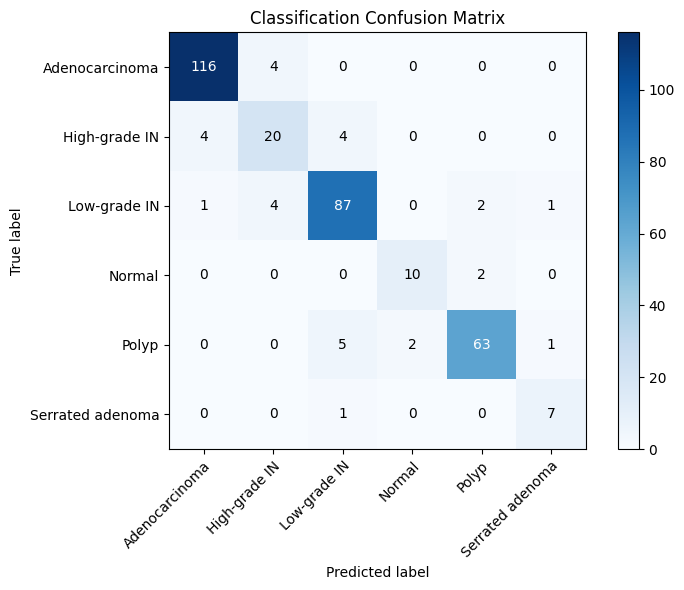

[Segmentation] Macro F1 (all classes): 0.8474
[Segmentation] Macro Recall (all classes): 0.8427
[Segmentation] Macro F1 (no background): 0.8404
[Segmentation] Macro Recall (no background): 0.8406


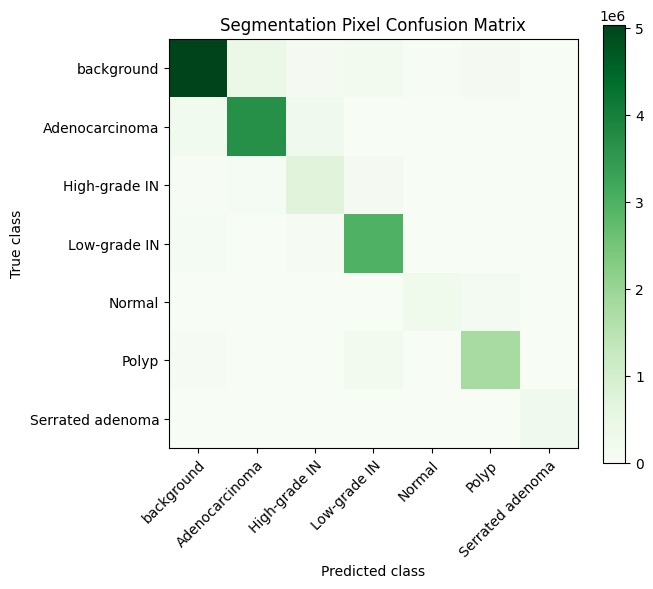

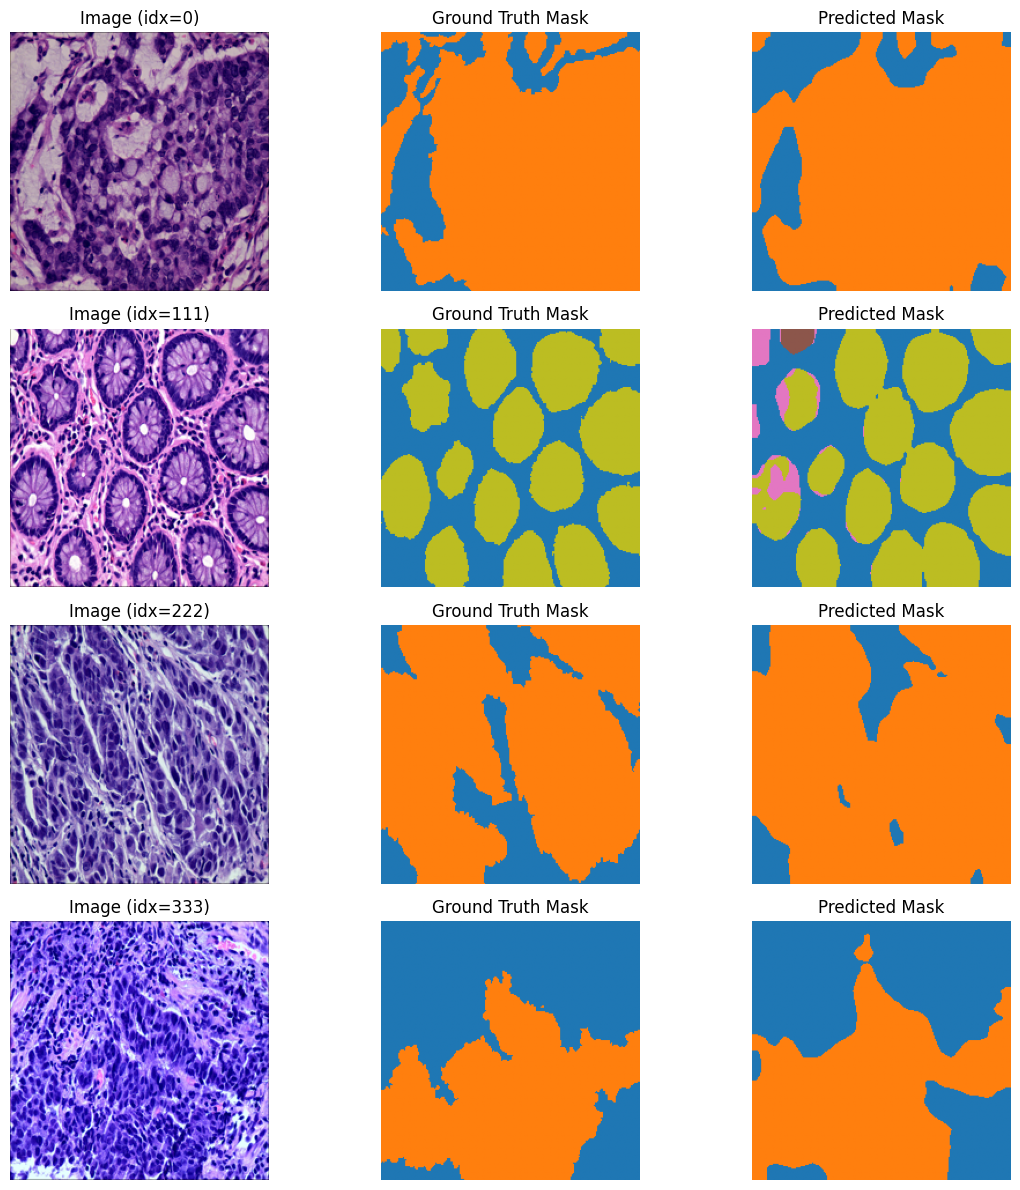

In [12]:
from sklearn.metrics import confusion_matrix, f1_score, recall_score

# Build class names in order.
class_table = (
    df[["class_id", "class_name"]]
    .drop_duplicates()
    .sort_values("class_id")
)
seg_class_names = ["background"] + class_table["class_name"].tolist()
cls_class_names = class_table["class_name"].tolist()

# -------------------------
# Classification metrics
# -------------------------
cls_model.eval()
all_cls_targets = []
all_cls_preds = []

with torch.no_grad():
    for images, targets in cls_test_loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        logits = cls_model(images)
        preds = torch.argmax(logits, dim=1)

        all_cls_targets.append(targets.cpu().numpy())
        all_cls_preds.append(preds.cpu().numpy())

all_cls_targets = np.concatenate(all_cls_targets)
all_cls_preds = np.concatenate(all_cls_preds)

cls_f1_macro = f1_score(all_cls_targets, all_cls_preds, average="macro")
cls_f1_weighted = f1_score(all_cls_targets, all_cls_preds, average="weighted")
cls_recall_macro = recall_score(all_cls_targets, all_cls_preds, average="macro")
cls_recall_weighted = recall_score(all_cls_targets, all_cls_preds, average="weighted")

print("[Classification] Macro F1:", round(float(cls_f1_macro), 4))
print("[Classification] Weighted F1:", round(float(cls_f1_weighted), 4))
print("[Classification] Macro Recall:", round(float(cls_recall_macro), 4))
print("[Classification] Weighted Recall:", round(float(cls_recall_weighted), 4))

cm_cls = confusion_matrix(all_cls_targets, all_cls_preds, labels=list(range(NUM_CLS_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_cls, interpolation="nearest", cmap="Blues")
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(NUM_CLS_CLASSES),
    yticks=np.arange(NUM_CLS_CLASSES),
    xticklabels=cls_class_names,
    yticklabels=cls_class_names,
    xlabel="Predicted label",
    ylabel="True label",
    title="Classification Confusion Matrix",
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

threshold = cm_cls.max() / 2.0 if cm_cls.max() > 0 else 0
for i in range(cm_cls.shape[0]):
    for j in range(cm_cls.shape[1]):
        ax.text(
            j,
            i,
            format(cm_cls[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm_cls[i, j] > threshold else "black",
        )
plt.tight_layout()
plt.show()

# -------------------------
# Segmentation metrics
# -------------------------
seg_model.eval()
cm_seg = np.zeros((NUM_SEG_CLASSES, NUM_SEG_CLASSES), dtype=np.int64)

with torch.no_grad():
    for images, masks in seg_test_loader:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        logits = seg_model(images)["out"]
        preds = torch.argmax(logits, dim=1)

        true_np = masks.cpu().numpy().reshape(-1)
        pred_np = preds.cpu().numpy().reshape(-1)

        valid = (true_np >= 0) & (true_np < NUM_SEG_CLASSES)
        hist = np.bincount(
            NUM_SEG_CLASSES * true_np[valid] + pred_np[valid],
            minlength=NUM_SEG_CLASSES ** 2,
        ).reshape(NUM_SEG_CLASSES, NUM_SEG_CLASSES)
        cm_seg += hist


tp = np.diag(cm_seg).astype(np.float64)
fp = cm_seg.sum(axis=0) - tp
fn = cm_seg.sum(axis=1) - tp

precision = tp / (tp + fp + 1e-9)
recall = tp / (tp + fn + 1e-9)
f1 = 2.0 * precision * recall / (precision + recall + 1e-9)

seg_macro_f1_all = float(np.mean(f1))
seg_macro_recall_all = float(np.mean(recall))
seg_macro_f1_no_bg = float(np.mean(f1[1:]))
seg_macro_recall_no_bg = float(np.mean(recall[1:]))

print("[Segmentation] Macro F1 (all classes):", round(seg_macro_f1_all, 4))
print("[Segmentation] Macro Recall (all classes):", round(seg_macro_recall_all, 4))
print("[Segmentation] Macro F1 (no background):", round(seg_macro_f1_no_bg, 4))
print("[Segmentation] Macro Recall (no background):", round(seg_macro_recall_no_bg, 4))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_seg, interpolation="nearest", cmap="Greens")
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(NUM_SEG_CLASSES),
    yticks=np.arange(NUM_SEG_CLASSES),
    xticklabels=seg_class_names,
    yticklabels=seg_class_names,
    xlabel="Predicted class",
    ylabel="True class",
    title="Segmentation Pixel Confusion Matrix",
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

# -------------------------
# Show 4 segmentation samples
# -------------------------
num_show = min(4, len(seg_test_ds))
indices = np.linspace(0, len(seg_test_ds) - 1, num_show, dtype=int)

inv_mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
inv_std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(num_show, 3, figsize=(12, 3 * num_show))
if num_show == 1:
    axes = np.expand_dims(axes, axis=0)

for row_i, idx in enumerate(indices):
    image_t, gt_mask_t = seg_test_ds[idx]

    with torch.no_grad():
        out = seg_model(image_t.unsqueeze(0).to(DEVICE))["out"]
        pred_mask_t = torch.argmax(out, dim=1).squeeze(0).cpu()

    image_vis = image_t.clone() * inv_std + inv_mean
    image_vis = image_vis.clamp(0, 1).permute(1, 2, 0).numpy()

    axes[row_i, 0].imshow(image_vis)
    axes[row_i, 0].set_title(f"Image (idx={idx})")
    axes[row_i, 0].axis("off")

    axes[row_i, 1].imshow(gt_mask_t.numpy(), cmap="tab10", vmin=0, vmax=NUM_SEG_CLASSES - 1)
    axes[row_i, 1].set_title("Ground Truth Mask")
    axes[row_i, 1].axis("off")

    axes[row_i, 2].imshow(pred_mask_t.numpy(), cmap="tab10", vmin=0, vmax=NUM_SEG_CLASSES - 1)
    axes[row_i, 2].set_title("Predicted Mask")
    axes[row_i, 2].axis("off")

plt.tight_layout()
plt.show()